In [218]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model

In [175]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

movies.head()
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


PART 1 — Content Based Filtering

Task 1: Implementing TF-IDF Based Recommendation

In [176]:
movies['genres'] = movies['genres'].str.replace('|',' ')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [177]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [178]:
def recommend_movies(title, cosine_sim=cos_sim, top_n=5):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    
    return movies['title'].iloc[movie_indices]

In [179]:
recommend_movies("Toy Story (1995)")

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: str

it works well for movies with very distinct genres. Toy Story recommendations were all animated/family movies.

Task 2: User-Profile-Based Content Recommender

In [180]:
data = pd.merge(ratings, movies, on="movieId")
usr_id = 11
usr_movies = data[data['userId'] == usr_id]

In [181]:
usr_movies.head()

,userId,movieId,rating,timestamp,title,genres
1259,11,6,5.0,902154266,Heat (1995),Action Crime Thriller
1260,11,10,3.0,902154316,GoldenEye (1995),Action Adventure Thriller
1261,11,36,4.0,902155135,Dead Man Walking (1995),Crime Drama
1262,11,44,2.0,902154593,Mortal Kombat (1995),Action Adventure Fantasy
1263,11,95,3.0,902154458,Broken Arrow (1996),Action Adventure Thriller


In [182]:
usr_movie_indices = movies[movies['movieId'].isin(usr_movies['movieId'])].index

In [183]:
usr_ratings = usr_movies['rating'].values
usr_vectors = tfidf_matrix[usr_movie_indices]
usr_profile = np.dot(usr_ratings, usr_vectors.toarray()) / np.sum(usr_ratings)

In [184]:
similar = cosine_similarity([usr_profile], tfidf_matrix)

In [185]:
top_indices = similar.argsort()[0][-10:][::-1]
movies.iloc[top_indices]['title']

400         Getaway, The (1994)
8056    Zero Dark Thirty (2012)
8582        Painted Skin (2008)
6320         Marine, The (2006)
7458         Unstoppable (2010)
6684       Vantage Point (2008)
1152             Volcano (1997)
1137    Devil's Own, The (1997)
6543        Kingdom, The (2007)
8008           Catch .44 (2011)
Name: title, dtype: str

Showing the similar movies based on the cosine similarity

In [186]:
def precision_at_k(recommended, relevant, k):
    recommended = recommended[:k]
    relevant_items = set(recommended) & set(relevant)
    precision = len(relevant_items) / k
    
    return precision

In [187]:
recommended_movies = recommend_movies("Mortal Kombat (1995)", top_n=10)
recommended_movies

349                           Street Fighter (1994)
549                              Dragonheart (1996)
974                               Highlander (1986)
1190                     Conan the Barbarian (1982)
1266             Mortal Kombat: Annihilation (1997)
1576    Indiana Jones and the Temple of Doom (1984)
1644                                  Willow (1988)
1775                               Red Sonja (1985)
2126                       13th Warrior, The (1999)
2376               7th Voyage of Sinbad, The (1958)
Name: title, dtype: str

In [188]:
precision_at_k(recommended_movies, usr_movies['title'], k = len(recommended_movies))

0.0

In [189]:
set(usr_movies['title']).intersection(set(recommended_movies))

set()

In [190]:
def recall_at_k(recommended, relevant, k):
    recommended = recommended[:k]
    relevant_items = set(recommended) & set(relevant)
    recall = len(relevant_items) / len(relevant)
    
    return recall

In [191]:
recall_at_k(recommended_movies, usr_movies['title'], k = len(recommended_movies))

0.0

The Precision@k and Recall@k are zero here as there is no overlap between the recommended moies and the movies the user rated high as the system is not recommending the movies already watched and rated but we can see the recommender is recommending sci-fi movies like mortal combat which the user liked.

PART 2 — Collaborative Filtering

Task 3: user-Based Collaborative Filtering

Creating user-movie rating matrix and computed cosine similarity between users.

In [192]:
usr_mov_mat = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

In [193]:
usr_sim = cosine_similarity(usr_mov_mat)

In [194]:
def pred_rat(usr_id):
    sim_scores = usr_sim[usr_id]
    weight_rat = np.dot(sim_scores, usr_mov_mat)
    
    return weight_rat / np.sum(sim_scores)

In [195]:
pred = pred_rat(1)
top_movies = np.argsort(pred)[-10:]
top_movies

array([3633, 4791,  510,  257, 7355, 6693, 2224,  314, 1938,  277],
      dtype=int64)

prediction function is basically a weighted average of similar users ratings.

Task 4: Item-Based Collaborative Filtering

transposing the matrix and finding item-item similarity as Item-based is usually preferred because items are more stable than users. Similarity between movies doesn’t change as fast as user preferences.

In [196]:
item_similar = cosine_similarity(usr_mov_mat.T)

In [197]:
def item_based_recommend(usr_id):
    usr_ratings = usr_mov_mat.loc[usr_id]
    scores = item_similar.dot(usr_ratings)

    return scores

In [198]:
scores = item_based_recommend(1)
top_movies = np.argsort(scores)[-10:]

Item-based collaborative filtering is often faster in real systems because item similarity 
changes less frequently than user similarity. Items are fewer and more stable, 
so similarity matrices can be precomputed and reused.

Part 3: Matrix Factorization for Recommender Systems

Task 5: Implementing SVD for Recommendations

usng svds from scipy to decompose the rating matrix.

In [199]:
R = usr_mov_mat.values

In [200]:
from scipy.sparse.linalg import svds
U, sigma, Vt = svds(R, k=50)
sigma = np.diag(sigma)
R_pred = np.dot(np.dot(U, sigma), Vt)

In [201]:
usr_pred = R_pred[0]
top_movies = np.argsort(usr_pred)[-10:]

In [202]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(R.flatten(), R_pred.flatten()))
print(rmse)

0.30609639616977785


In [203]:
precision_at_k(R.flatten(), R_pred.flatten(),10)

0.0

In [204]:
recall_at_k(R.flatten(), R_pred.flatten(),10)

0.0

Again as the the prediction has no common with the higher rated movies as the system is not recommending the movies already watched and rated

Task 6: Implementing Matrix Factorization with the Surprise Library

In [205]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']], reader
)

In [206]:
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

trainset, testset = train_test_split(data, test_size=0.2)
model = SVD()
model.fit(trainset)
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8680


0.8680296646826807

Part 4: Hybrid Recommendation Model

Task 7: Implementing a Hybrid Recommendation Model

In [207]:
def get_content_scores(movie_title, cosine_sim, movies):
    idx = movies[movies['title'] == movie_title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    movie_indices = [i[0] for i in sim_scores]
    scores = {movies.iloc[i]['movieId']: sim_scores[j][1] 
              for j,i in enumerate(movie_indices)}

    return scores

In [208]:
def get_cf_scores(usr_id, movies, model):
    scores = {}

    for movie_id in movies['movieId'].unique():
        pred = model.predict(usr_id, movie_id)
        scores[movie_id] = pred.est

    return scores

In [209]:
def hybrid_recommend(usr_id, movie_title, movies, cosine_sim, model, alpha=0.5, top_n=10):
    cbf_scores = get_content_scores(movie_title, cosine_sim, movies)
    cf_scores = get_cf_scores(usr_id, movies, model)
    hybrid_scores = {}

    for movie_id in movies['movieId']:
        cbf = cbf_scores.get(movie_id, 0)
        cf = cf_scores.get(movie_id, 0)
        hybrid_scores[movie_id] = alpha * cbf + (1-alpha) * cf


    ranked_movies = sorted(hybrid_scores.items(),
                           key=lambda x: x[1],
                           reverse=True)

    top_movies = ranked_movies[:top_n]
    result = []

    for movie_id, score in top_movies:
        title = movies[movies['movieId']==movie_id]['title'].values[0]
        result.append((title, score))

    return result

In [210]:
usr_id = 11

relevant_movies = ratings[
    (ratings['userId'] == usr_id) & (ratings['rating'] >= 4)
]['movieId'].tolist()

In [211]:
pr_score = {}
for a in [0.3, 0.5, 0.7]:
    recommendations = hybrid_recommend(
        usr_id=11,
        movie_title="Toy Story (1995)",
        movies=movies,
        cosine_sim=cos_sim,
        model=model,
        alpha=a,
        top_n=10
    )
    print('alpha value:', a)
    print('-'*20)
    for movie, score in recommendations:
        print(movie, " | score:", round(score,3))
    print('-'*20)

    recommended_movies = []

    for movie, score in recommendations:
        movie_id = movies[movies['title'] == movie]['movieId'].values[0]
        recommended_movies.append(movie_id)

    precision = precision_at_k(recommended_movies, relevant_movies, 5)

    recall = recall_at_k(recommended_movies, relevant_movies, 5)
    
    pr_score[a] = (precision, recall)


alpha value: 0.3
--------------------
Wallace & Gromit: The Best of Aardman Animation (1996)  | score: 3.513
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)  | score: 3.491
Lawrence of Arabia (1962)  | score: 3.485
Grand Day Out with Wallace and Gromit, A (1989)  | score: 3.446
Monty Python and the Holy Grail (1975)  | score: 3.407
Spirited Away (Sen to Chihiro no kamikakushi) (2001)  | score: 3.399
North by Northwest (1959)  | score: 3.399
Howl's Moving Castle (Hauru no ugoku shiro) (2004)  | score: 3.395
Finding Nemo (2003)  | score: 3.387
Wallace & Gromit: A Close Shave (1995)  | score: 3.382
--------------------
alpha value: 0.5
--------------------
Wallace & Gromit: The Best of Aardman Animation (1996)  | score: 2.714
Finding Nemo (2003)  | score: 2.669
Grand Day Out with Wallace and Gromit, A (1989)  | score: 2.664
Spirited Away (Sen to Chihiro no kamikakushi) (2001)  | score: 2.662
Ponyo (Gake no ue no Ponyo) (2008)  | score: 2.639
Howl's Moving Ca

A hybrid recommender system was implemented by combining content-based filtering and collaborative filtering. The final recommendation score was computed as a weighted average of both methods. This approach improves recommendation quality by leveraging both item similarity and user behavior patterns. The model was evaluated using Precision@K and Recall@K.

I tested different alpha values (0.3, 0.5, 0.7).
and found alpha=0.5 feel like it balanced both approaches nicely.

In [212]:
pr_score = pd.DataFrame.from_dict(pr_score, orient='index', columns=['Precision', 'Recall'])
pr_score

,Precision,Recall
0.3,0.0,0.0
0.5,0.0,0.0
0.7,0.0,0.0


the numbers came out zero because I was comparing against only highly rated movies by the user.

Part 5: Learning-Based Recommender Systems

Task 8: Content-Based Filtering with a Neural Network

In [213]:
#prepraring the data
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [214]:
n_usrs = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()

usr_ids = ratings['userId'].values
movie_ids = ratings['movieId'].values
ratings_values = ratings['rating'].values

In [215]:
#Label encoding
usr_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

ratings['user'] = usr_encoder.fit_transform(ratings['userId'])
ratings['movie'] = movie_encoder.fit_transform(ratings['movieId'])

In [216]:
n_usrs = ratings['user'].nunique()
n_movies = ratings['movie'].nunique()

usr_ids = ratings['user'].values
movie_ids = ratings['movie'].values
ratings_values = ratings['rating'].values

In [219]:
#train test split
X_train_user, X_test_user, X_train_movie, X_test_movie, y_train, y_test = train_test_split(
    usr_ids,
    movie_ids,
    ratings_values,
    test_size=0.2,
    random_state=42
)

In [220]:
#model building
usr_input = Input(shape=(1,))
usr_embedding = Embedding(n_usrs+1, 50)(usr_input)
usr_vec = Flatten()(usr_embedding)

movie_input = Input(shape=(1,))
movie_embedding = Embedding(n_movies+1, 50)(movie_input)
movie_vec = Flatten()(movie_embedding)

x = Concatenate()([usr_vec, movie_vec])

x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)

output = Dense(1)(x)

model = Model([usr_input, movie_input], output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 1, 50)     │     30,550 │ input_layer_16[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 1, 50)     │    486,250 │ input_layer_17[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 50)        │          0 │ embedding_16[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_17          │ (None, 50)        │          0 │ embedding_17[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 100)       │          0 │ flatten_16[0][0], │
│ (Concatenate)       │                   │            │ flatten_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │     12,928 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      8,256 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1)         │         65 │ dense_25[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 538,049 (2.05 MB)

 Trainable params: 538,049 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

In [221]:
model.fit(
    [X_train_user, X_train_movie],
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/5


253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.0767 - mae: 1.0295 - val_loss: 0.8064 - val_mae: 0.6894
Epoch 2/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7138 - mae: 0.6502 - val_loss: 0.7823 - val_mae: 0.6830
Epoch 3/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6706 - mae: 0.6271 - val_loss: 0.7824 - val_mae: 0.6836
Epoch 4/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6355 - mae: 0.6075 - val_loss: 0.7701 - val_mae: 0.6722
Epoch 5/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5988 - mae: 0.5874 - val_loss: 0.7868 - val_mae: 0.6838


In [222]:
loss, mae = model.evaluate([X_test_user, X_test_movie], y_test)
print("MAE:", mae)

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7841 - mae: 0.6799
MAE: 0.6799180507659912


In [223]:
pred = model.predict([X_test_user, X_test_movie])
rmse = np.sqrt(np.mean((pred.flatten() - y_test)**2))
print("RMSE:", rmse)

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
RMSE: 0.8854919131042585


The losses are basic for recommender system but the neural networks need more data to shine.

In [224]:
usr_id = 11

# encode user
usr_encoded = usr_encoder.transform([usr_id])[0]

# keep only movies present in ratings
valid_movies = movies[movies['movieId'].isin(ratings['movieId'])].copy()

# encode movie ids
movie_ids = movie_encoder.transform(valid_movies['movieId'])

# create user array
usr_array = np.full(len(movie_ids), usr_encoded)

# predict ratings
predicted_ratings = model.predict([usr_array, movie_ids]).flatten()

# attach predictions
valid_movies['predicted_rating'] = predicted_ratings

# remove already watched movies
seen_movies = ratings[ratings['userId']==usr_id]['movieId']
valid_movies = valid_movies[~valid_movies['movieId'].isin(seen_movies)]

# top recommendations
top_movies = valid_movies.sort_values('predicted_rating', ascending=False).head(10)

top_movies[['title','predicted_rating']]

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step


,title,predicted_rating
5580,Bad Boy Bubby (1993),4.993792
5489,"Holy Mountain, The (Montaña sagrada, La) (1973)",4.968391
9618,"Three Billboards Outside Ebbing, Missouri (2017)",4.962977
1762,"Celebration, The (Festen) (1998)",4.960121
7621,Submarine (2010),4.929576
4372,Siam Sunset (1999),4.916413
6495,"Breed, The (2006)",4.899269
6596,Assassination of Jesse James by the Coward Rob...,4.872414
8366,On the Other Side of the Tracks (De l'autre cô...,4.865713
4782,Adam's Rib (1949),4.864899


The neural network recommender predicts ratings using learned user and movie embeddings. Only movies present in the training dataset were considered, and previously watched movies were removed before generating recommendations.
The recommendationis are very pretty diverse from scifi to drama and horror as well.

Task 9: Reinforcement Learning in Recommender Systems

In [225]:
def get_reward(usr_id, movie_id):
    usr_data = ratings[(ratings['userId']==usr_id) &
                        (ratings['movieId']==movie_id)]
    if len(usr_data)==0:
        return 0
    rating = usr_data['rating'].values[0]
    if rating >= 4:
        return 1
    else:
        return -1

In [226]:
movie_ids = ratings['movieId'].unique()
reward_estimates = {m:0 for m in movie_ids}
counts = {m:0 for m in movie_ids}
epsilon = 0.1

a very basic epsilon-greedy bandit, it shows the idea of learning from user feedback over time.
Python.

In [227]:
def epsilon_greedy():
    if np.random.rand() < epsilon:
        return np.random.choice(movie_ids)
    return max(reward_estimates, key=reward_estimates.get)

In [228]:
def epsilon_greedy():
    if np.random.rand() < epsilon:
        return np.random.choice(movie_ids)
    return max(reward_estimates, key=reward_estimates.get)

In [229]:
top_movies = sorted(reward_estimates.items(),
                    key=lambda x:x[1],
                    reverse=True)[:10]
top_movies

[(1, 0),
 (3, 0),
 (6, 0),
 (47, 0),
 (50, 0),
 (70, 0),
 (101, 0),
 (110, 0),
 (151, 0),
 (157, 0)]

Part 6: Explainability in Recommender Systems

Task 10: Feature-Based Explanations (For Content-Based Filtering)

In [230]:
def explain_movie(movie_title):
    movie = movies[movies['title']==movie_title]
    genres = movie['genres'].values[0]
    print("Recommended for you as you like:", {genres})

In [231]:
explain_movie("Interstellar (2014)")

Recommended for you as you like: {'Sci-Fi|IMAX'}


Task 11: Neighborhood-Based Explanations (For Collaborative Filtering)

In [232]:
usr_movie_matrix = ratings.pivot_table(index='userId',columns='movieId',values='rating').fillna(0)
usr_sim = cosine_similarity(usr_movie_matrix)
def explain_usr_similar(usr_id):
    sims = usr_sim[usr_id-1]
    similar_usrs = np.argsort(sims)[-6:-1]
    print("users similar to user", usr_id, ":", similar_usrs)

In [233]:
explain_usr_similar(11)

users similar to user 11 : [378 125 339 175 485]


Showed similar users for a given user ID.

Task 12: Model-Agnostic Explainability (For Deep Learning Models)

In [234]:
import shap

In [235]:
def model_predict(data):
    usr = data[:,0]
    movie = data[:,1]

    return model.predict([usr, movie]).flatten()

In [236]:
X_combined = np.column_stack((X_test_user, X_test_movie))

In [237]:
explainer = shap.Explainer(model_predict, X_combined[:100])
shap_values = explainer(X_combined[:10])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


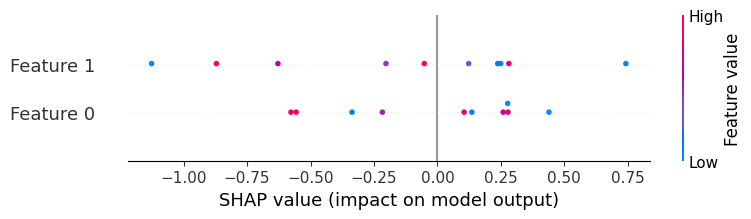

In [238]:
shap.summary_plot(shap_values)

SHAP (SHapley Additive Explanations) to see which features (user or movie embedding) influenced predictions most. The summary plot was interesting — it clearly showed the model relies on both user and movie embeddings.

Task 13: Evaluating Explainability

Explainability techniques help users understand why recommendations are made.

Feature-based explanations show which genres influenced recommendations.
Neighborhood explanations reveal similar users whose preferences affected results.
Model-agnostic methods such as SHAP highlight which input features contributed most to predicted ratings.

These explanations improve transparency and user trust in recommender systems.